In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import datetime as dt

In [18]:
df = pd.read_csv('FINA4359 database +btc.csv')
df.columns = ['time','btc','dbc','gld','ief','spy','svxy','tlt']
df = df.set_index('time')
df = df.drop(columns=['btc','svxy'])
df.head()

,dbc,gld,ief,spy,tlt
time,,,,,
17/9/2014,20.273594,117.540001,79.560547,164.567474,82.256111
18/9/2014,20.079144,117.779999,79.506294,165.444672,82.518593
19/9/2014,20.019962,117.089996,79.808617,165.295608,83.568680
22/9/2014,19.850876,116.849998,79.979179,164.019058,83.670753
23/9/2014,19.850876,117.599998,80.149689,163.080093,84.188515


In [23]:
ret = df.pct_change()
vol = ret.rolling(252).std()

In [30]:
ws = ret.std() / ret.std().sum()
ws

dbc    0.244954
gld    0.218521
ief    0.090245
spy    0.242100
tlt    0.204180
dtype: float64

# Change of risk

<Axes: xlabel='time'>

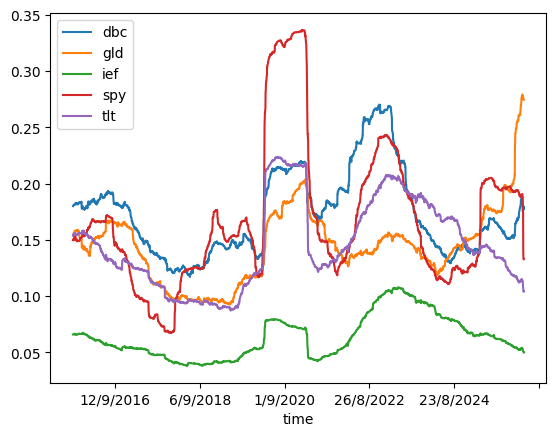

In [24]:
(vol*np.sqrt(252)).plot()

## After risk parity

<Axes: xlabel='time'>

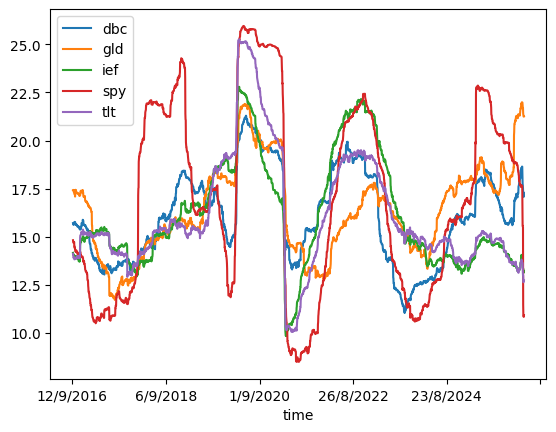

In [31]:
norm_ret = ret.div(vol.shift(1))
norm_risk = norm_ret.rolling(252).std()
(norm_risk*np.sqrt(252)).plot()

<Axes: xlabel='time'>

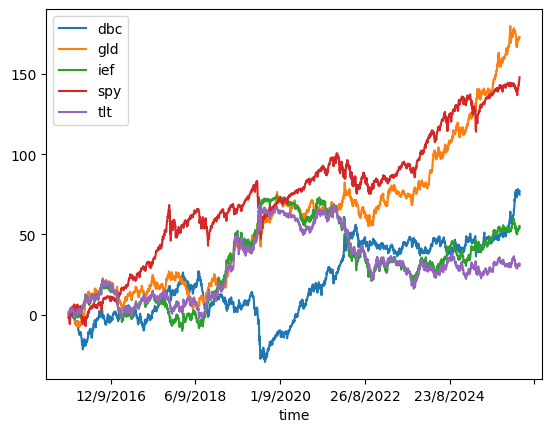

In [33]:
norm_ret.cumsum().plot()

<Axes: xlabel='time'>

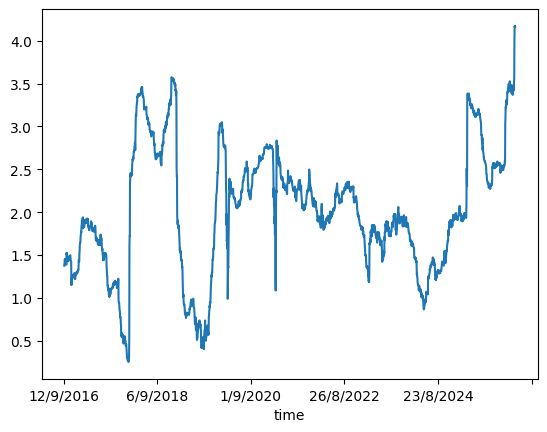

In [26]:
risk_depeg = (norm_risk*np.sqrt(252)).std(axis=1)
risk_depeg.plot()